In [149]:
import os, sys
sys.path.append("../../")

import numpy as np
import jax.numpy as jnp
from jax import grad, vmap, jit, lax
import jax
import jax.random as jr
import equinox as eqx 
from functools import partial
from tqdm import trange
import time

import matplotlib.pyplot as plt
import h5py # partial array reading
from utils.model import DR1, DR2, FNO2d
from utils.ac.utils import compare_DR
from utils.ac.explicite import DR1_next, DR2_next
from utils.ac.benchmark import eval_num, eval_NN
from utils.helper import count_parameters

#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.45"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
#%set_env XLA_PYTHON_CLIENT_ALLOCATOR=platform


### Fix Slurm output
from utils.helper import tqdm_slurm
tqdm_slurm(5)


In [150]:
key = jax.random.PRNGKey(0)

## Allen-Cahn equation : 

$$
\partial_t u(t, x) = C(\Delta u + \epsilon^{-2}(u - u^3))    
$$
with $\epsilon = 1/64$, 
for all $x \in [0, 1]^2$ and $t \in [0, 0.4]$. We also consider either zero Neumann boundary condition or  solutions in periodic spaces.

In case where the initial conditions are well-prepared (Evans et al.), the solutions to Allen-Cahn equation correspond to the mean curvature flow : 
$$
V = C H.
$$


Splitting scheme : 
$$ 
\frac{u_{n+1} - u_n}{dt} =  C \left ( (\Delta u_{n+1} - \alpha \epsilon^{-2} u_{n+1}) + \epsilon^{-2}((u_n - u^3_{n}) + \alpha u_n)
\right )
$$

In [151]:
f64 = True 
jax.config.update("jax_enable_x64", f64) # jax FFT bug...
# %%

## Physics parameters
N_x = 128 #+ 1
N_y = N_x#+ 1
T_0 = 0.
#C = 10 * (40**(-2))
C = 1
x_lb = 0 
x_rb = 1
y_lb = 0 
y_ub = 1
dx = (x_rb - x_lb)/(N_x)
eps = 1/64
n_space = 256 // N_x
dt_fdm = eps**2
dt = dt_fdm
#assert(dt_fdm <=(dx)**2/(4*10*(40**(-2)))) # CFL condition
# Nt_fdm  =  jnp.floor(T_final/dt_fdm).astype(int)
alpha = 2.001

## Training 
n_epoch = 2_000
n_LBFGS = 1_000
loss_history = []


## NN Hyperparameters
method = 1
kernel_size = 17
# modes1 = 20
# modes2 = 20
width = 10
n_layers = 2


data_path = f"../../explicite/mcf_modes6-180samples-Nx256-Tf2.44e-04-alpha2.001"
train_path = f"{data_path}.h5c"
in_test_path = f"{data_path}_in-test.h5c"
out_test_path = f"{data_path}_out-test.h5c"
h5f = h5py.File(f"{train_path}", mode='r')
#print(h5f.keys())
u_fdm = (h5f['u_sols'][:, 0, ::n_space, ::n_space])

### Import helper functions

In [152]:
xs, ys = jnp.meshgrid(
    jnp.linspace(0, 1, N_x, endpoint=False), 
    jnp.linspace(0, 1, N_y, endpoint=False), 
    indexing='ij'
    )

In [153]:
key, fnokey = jr.split(key)
gamma_10 = 1.

# RDNO
DR_next = partial(DR1_next, 
                  N_x = N_x, N_y = N_y, 
                  dx = dx, 
                  dt = dt, 
                  eps =eps, 
                  alpha = alpha, 
                  C =1, gamma_10 = 1.)
model_rdno = DR1(
    in_channels=1, out_channels=1, width=width, 
    activation=jax.tree_util.Partial(jax.nn.tanh), 
    kernel_size = kernel_size, 
    n_layers= n_layers, key=fnokey
    )
model_name = "RDNO"
rdno_path = f"acDR{method}var-kr{kernel_size}-w{width}-l{n_layers}_bs{32}-Nx{N_x}-dt{dt:.2e}-alpha{alpha}"


if os.path.exists(f"{rdno_path}.eqx"):
    model_rdno = eqx.tree_deserialise_leaves(f"{rdno_path}.eqx", model_rdno)
else:
    raise Exception("Model not found in model_path !")
# RDNO-data
model_rdno_data = DR1(
            in_channels=1, out_channels=1, width=width, 
            activation=jax.tree_util.Partial(jax.nn.tanh), 
            kernel_size = kernel_size, 
            n_layers= n_layers, key=fnokey
            )
model_rdno_data = eqx.tree_deserialise_leaves(f"acDR1_data-kr17-w10-l2_bs_data32-Nx128-dt2.44e-04-alpha2.001.eqx", model_rdno_data)

# UNet 
from utils.models.UNet import UNet
hidden_channels = 2
num_levels = 4
model_Unet = UNet(
    2, 1, 1, hidden_channels= hidden_channels, num_levels= num_levels, 
    activation = (jax.nn.tanh), 
    key = fnokey
)
unet_path = f"ac-UNetvar-h2-numlv4-bs32-180samples-Nx128-dt0.000244140625-alpha2.001"
#unet_path = f"ac-UNetvar-h2-numlv4-bs16-180samples-Nx128-dt0.000244140625-alpha2.001"
model_Unet = eqx.tree_deserialise_leaves(f"{unet_path}.eqx", model_Unet)

# UNet-Data
model_Unet_data = UNet(
    2, 1, 1, hidden_channels= hidden_channels, num_levels= num_levels, 
    activation = (jax.nn.tanh), 
    key = fnokey
)
model_Unet_data  = eqx.tree_deserialise_leaves(f"ac-data-UNetvar-h2-numlv4-bs16-180samples-Nx128-dt0.000244140625-alpha2.001.eqx", model_Unet_data)


# FNO 

class Splino(eqx.Module):
    Net: FNO2d
    def __init__(
            self,  modes1, modes2, width, activation, n_blocks, *, key
    ): 
        self.Net = FNO2d(1, 1, modes1, modes2, width, activation=activation, n_blocks=n_blocks, key = key)
    
    def __call__(self, 
                 *x,
                 ): 
        x = jnp.stack(x, axis=0)

        return self.Net(x) 

model_fno = Splino(modes1=20, modes2=20, width=16, activation=jax.nn.tanh, n_blocks= 4, key=fnokey)
fno_path = f"ac-FNO-split{20}-{16}-{4}_{32}phys-Nx{N_x}-dt{dt:.2e}-alpha{alpha}"
model_fno = eqx.tree_deserialise_leaves(f"{fno_path}.eqx", model_fno)

print("All Trained Models found !")


print(f"train. params: RDNO {count_parameters(model_rdno)} | UNet {count_parameters(model_Unet)} | FNO {count_parameters(model_fno)}"
)

All Trained Models found !
train. params: RDNO 31522 | UNet 37021 | FNO 821475


In [154]:
from utils.ac.utils import energy
energy = eqx.filter_jit(partial(energy, N_x = N_x, N_y = N_y, dx = dx, eps=eps))
from utils.ac.benchmark import eval_num, eval_NN
eval_num = partial(eval_num, dt=dt, DR_next=DR_next, energy=energy)
eval_NN = (partial(eval_NN, dt=dt, energy=energy))

$$ 
u_{n+1} = K_2  * \rho_2 (u_n)
$$ 
where 
$$ 
K_2 (x) = \mathcal{F}^{-1} \left [ 
\xi \mapsto \frac{1}{1+ C\delta_t (4\pi^2 |\xi|^2 + \alpha \epsilon^{-2})}
\right ]
$$

and $\rho_2 (s) =  s - \frac{C\delta_t}{\epsilon^2} ( (s^3 -s ) - \alpha s)$.

In [155]:
# %%
key, tr_key = jr.split(key)
#idx_val = jr.choice(val_key, jnp.arange(n_sample + n_sample_val), shape=(n_sample_val, ), replace = False)
#idx_train = np.delete(np.arange(n_sample + n_sample_val),  idx_val)
#idx_train = np.arange(n_sample)

In [156]:
def compare_NN(f_init, model, freq = 10, savepath = None):
    u_NN = f_init
    u_num = f_init
    energy_NN = [energy(f_init)]
    energy_num = [energy(f_init)]

    error_list = []

    plt.figure(figsize=(25, 10))
    L = 3
    for i in range(5): 
        T= (i)*dt*freq

        plt.subplot(L, 1, 1)
        plt.title(f'$u_{{NN}}$', rotation='vertical', x= -0.01, y =0.5);
        plt.axis('off')
        plt.subplot(L, 5, 1+i)
        plt.imshow(u_NN, cmap='rainbow', extent=[x_lb, x_rb, y_lb, y_ub], origin='lower', vmin=-1, vmax=1)
        plt.title(f"T={T:.2e}")
        plt.colorbar()
        plt.subplot(L, 1, 2)
        plt.title(f'$abs. error$', rotation='vertical', x= -0.01, y =0.5);
        plt.axis('off')
        plt.subplot(L, 5, 6+i)
        plt.imshow(abs(u_NN-u_num), cmap='rainbow', extent=[x_lb, x_rb, y_lb, y_ub], origin='lower')
        plt.title(f"T={T:.2e}")
        plt.colorbar()
        rel_err = abs(energy_NN[-1] - energy_num[-1])/energy_num[-1]
        error_list.append(rel_err)
        #print(f"Rel error of Perimeter for NN at T={T:.2e} : {rel_err:.2%}")
        for _ in range(freq):
            u_NN = model(u_NN)
            u_num = DR_next(u_num)

            energy_NN.append(energy(u_NN))
            energy_num.append(energy(u_num))

        time_list = dt*jnp.arange(len(energy_NN))
    plt.subplot(3, 1, 3) 
    plt.plot(time_list, energy_NN, label='Deep Ritz')
    plt.plot(time_list, energy_num, label='Splitting')
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Perimeter")
    print(f"Mean rel error over iterations : {jnp.mean(jnp.array(error_list))}")
        
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    # return energy_NN, energy_num

In [157]:
# def eval_DR(f_init, model, model2 = model2, freq =10, timestep = jnp.arange(5), 
#             model_name = None, savepath=None, included_num = True): 
#     u_NN = f_init
#     u_data = f_init
#     u_num = f_init
#     energy_NN = [energy(f_init)]
#     energy_data = [energy(f_init)]
#     energy_num = [energy(f_init)]
#     time_NN = 0
#     time_num = 0
#     time_data = 0
# 
#     import matplotlib 
#     matplotlib.rcParams.update({'font.size': 20})
# 
# #    if included_num: 
# #    #    plt.figure(figsize=(25, 10))
# #        L = 3
# #    else:
# #    #    plt.figure(figsize=(25, 7))
# #        L = 2
# #    fig, ax_list = plt.subplots(L, 5, figsize=(15, 3*L))
# #
# 
# 
#     # Plot first 4 images (no colorbar)
#     for i in range(4):
#         T= timestep[i]*dt*freq 
# #        ax_list[0, i].imshow(u_num, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #        if i ==0:
# #            ax_list[1, 0].axis("off")
# #            ax_list[2, 0].axis("off")
# #        if i >0:
# #            ax_list[1, i].imshow(u_NN, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #            ax_list[2, i].imshow(u_data, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #        for j in range(L):
# #            ax_list[j, i].set_xticks([])
# #            ax_list[j, i].set_yticks([])
# #        ax_list[0, i].set_title(f"T={T:.2e}")
# 
#         print(f"Rel error of Perimeter for NN at T={T:.2e} : {abs(energy_NN[-1] - energy_num[-1])/energy_num[-1]:.2%}")
#         print(f"Rel error of Perimeter for Data at T={T:.2e} : {abs(energy_data[-1] - energy_num[-1])/energy_data[-1]:.2%}")
# 
#         for _ in range(freq):
#             time_in = time.time()
#             u_NN = model(u_NN)
#             time_out = time.time()
#             time_NN += time_out - time_in
# 
#             time_in = time.time()
#             u_data = model2(u_data)
#             time_out = time.time()
#             time_data += time_out - time_in
# 
#             time_in = time.time()
#             u_num = DR_next(u_num)
#             time_out = time.time()
#             time_num += time_out - time_in
# 
#             energy_NN.append(energy(u_NN))
#             energy_data.append(energy(u_data))
#             energy_num.append(energy(u_num))
#         
#     # Plot last image + colorbar
#     T= timestep[4]*dt*freq 
# #    im_last = ax_list[0, 4].imshow(u_num, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #    fig.colorbar(im_last, ax=ax_list[0, 4], fraction=0.046, pad=0.04)
# #    im_last = ax_list[1, 4].imshow(u_NN, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #    fig.colorbar(im_last, ax=ax_list[1, 4], fraction=0.046, pad=0.04)
# #    im_last = ax_list[2, 4].imshow(u_data, cmap='rainbow', origin='lower', vmin=-1, vmax=1)
# #    fig.colorbar(im_last, ax=ax_list[2, 4], fraction=0.046, pad=0.04)
# #    for j in range(L):
# #        ax_list[j, 4].set_xticks([])
# #        ax_list[j, 4].set_yticks([])
# #    ax_list[0, 4].set_title(f"T={T:.2e}")
# #    plt.tight_layout()
# #    fig.text(-0.04, 0.8, "Reference", va="center", ha="center", fontsize=28, rotation=90)
# #    fig.text(-0.00, 0.8, "Splitting", va="center", ha="center", fontsize=32, rotation=90)
# #    if model_name:
# #        fig.text(-0.04, 0.5, "DeepRitzSplit", va="center", ha="center", fontsize=28, rotation=90)
# #        fig.text(-0.00, 0.5, model_name, va="center", ha="center", fontsize=32, rotation=90)
# #    fig.text(-0.04, 0.2, "Data-Driven", va="center", ha="center", fontsize=28, rotation=90)
# #    fig.text(0.00, 0.2, model_name, va="center", ha="center", fontsize=32, rotation=90)
#     
# 
#         
#     print(f"time_NN : {time_NN:.2e} | time_data : {time_data:.2e} | time_num : {time_num:.2e}")
#     energy_NN = np.array(energy_NN)
#     energy_data = np.array(energy_data)
#     print(f"Average NN Error : {jnp.mean((abs(energy_NN- energy_num)/energy_num)[1:3*freq+1]):.2%}")
#     print(f"Average Data Error : {jnp.mean((abs(energy_data- energy_num)/energy_num)[1:3*freq+1]):.2%}")
#     if savepath:
#         plt.savefig(savepath, bbox_inches='tight')
#     # return energy_NN, energy_num

In [158]:
t = -10

h5t = h5py.File(in_test_path, mode='r')
f_init =h5t['u_sols'][t, 0, ::n_space, ::n_space]


h5t = h5py.File(out_test_path, mode='r')
f_init2 =h5t['u_sols'][-10, 0, ::n_space, ::n_space]
if f64:
    f_init =jnp.float64(f_init)
    f_init2 =jnp.float64(f_init2)
r1 = 0.05
r2 = 0.12
r3 = 0.08

def multi_disks(x, y): 
    b1 = jnp.tanh( (r1 - jnp.sqrt((x-0.30)**2 + (y-0.18)**2))/(jnp.sqrt(2)*eps) ) 
    b2 = jnp.tanh( (r2 - jnp.sqrt((x-0.67)**2 + (y-0.53)**2))/(jnp.sqrt(2)*eps) ) 
    b3 = jnp.tanh( (r3 - jnp.sqrt((x-0.23)**2 + (y-0.8)**2))/(jnp.sqrt(2)*eps) ) 

    return jnp.amax(
        jnp.stack([b1, b2, b3], axis=0), 
        axis= 0
    )
multi = multi_disks(xs ,ys)
b1 = jnp.tanh( ( 0.1 - jnp.sqrt( (xs - 0.58)**2 + (ys-0.5)**2) )/(jnp.sqrt(2)*eps))
b2 = jnp.tanh( ( 0.1 - jnp.sqrt( (xs - 0.42)**2 + (ys-0.5)**2) )/(jnp.sqrt(2)*eps))
merge1 =jnp.amax( 
    jnp.stack([b1, b2], axis=0),
    axis=0
)
b1 = jnp.tanh( ( 0.1 - jnp.sqrt( (xs - 0.7)**2 + (ys-0.5)**2) )/(jnp.sqrt(2)*eps)) 
b2 = jnp.tanh( ( 0.1 - jnp.sqrt( (1.25*(xs - 0.43))**2 + (0.8*(ys-0.5))**2) )/(jnp.sqrt(2)*eps))
merge2 =jnp.amax( 
    jnp.stack([b1, b2], axis=0),
    axis=0
)

r_bd = 0.16
def big_disk(x, y): 
    return jnp.tanh( (r_bd - jnp.sqrt((x-0.5)**2 + (y-0.5)**2))/(jnp.sqrt(2)*eps) ) 
big = big_disk(xs , ys)
r_trans = 0.12
def translated_disk(x, y):
    return jnp.tanh( (r_trans - jnp.sqrt((0.8*(x-0.67))**2 + (1.25*(y-0.53))**2))/(jnp.sqrt(2)*eps) ) 
    #return jnp.tanh( (r_trans - jnp.sqrt((x-0.50)**2 + (y-0.50)**2))/(jnp.sqrt(2)*eps) ) 

translated =translated_disk(xs, ys) 

key, rkey = jr.split(key)
random_init = 0.9* jr.uniform(rkey, shape=(N_x, N_y), minval=-1, maxval=1)


In [159]:
def drawDiagram(f_init, freq_list = [0, 3, 10, 40, 100], config='OOD', ve=1.5, he=(-0.0035, -0.0025)): 
    u_splittings = eval_num(f_init, freq = freq_list, title_name = "(a)", r = 0, savepath="ac_" + config+ "_splitting.png")
    u_rdno = eval_NN(f_init, model_rdno, freq = freq_list)
    u_rdno_data = eval_NN(f_init, model_rdno_data, freq = freq_list)
    u_unet = eval_NN(f_init, model_Unet, freq = freq_list)
    u_unet_data = eval_NN(f_init, model_Unet_data, freq = freq_list)
    u_fno = eval_NN(f_init, model_fno, freq = freq_list)

    u_splittings = jnp.array(u_splittings)
    u_rdno = jnp.array(u_rdno)
    u_rdno_data = jnp.array(u_rdno_data)
    u_unet = jnp.array(u_unet)
    u_unet_data= jnp.array(u_unet_data)
    u_fno = jnp.array(u_fno)

    def acAbsoluteError(u_model, u_num, freq_list, r = 90, vmax=0.2, title_name=None, entete=None, savepath=None):
        import matplotlib
        matplotlib.rcParams.update({'font.size': 20})
        fig, ax_list = plt.subplots(1, 5, figsize=(15, 3))
        for (i,freq) in enumerate(freq_list):
            ax_list[0].axis("off")
            if i ==0:
                continue
            T=dt*freq
            abs_err = abs(u_model[freq]-u_num[freq])
            im = ax_list[i].imshow(abs_err, origin='lower', vmin=0, vmax=vmax, cmap='inferno')
            print(f"max abs_err at {freq} : {jnp.max(abs_err)}")
            ax_list[i].set_xticks([])
            ax_list[i].set_yticks([])
            ax_list[i].set_title(f"T={T:.2e}")
            if i == 4: 
                fig.colorbar(im, ax=ax_list[4], fraction=0.046, pad=0.04)
        if title_name: 
            fig.text(0.1, 0.5, title_name, va="center", ha="center", fontsize=32, rotation=0)
        if entete:
            fig.text(0.15, 0.5, entete, va="center", ha="center", fontsize=28, rotation=r)
        if savepath:
            plt.savefig(savepath, bbox_inches='tight')

    acAbsoluteError(u_rdno, u_splittings, freq_list, title_name="(c)", entete="RDNO", savepath="ac_" + config+ "_rel_erro_rdno.png")
    acAbsoluteError(u_rdno_data, u_splittings, freq_list, title_name="(d)", entete="RDNO-data", savepath="ac_" + config+ "_rel_erro_rdno_data.png")
    acAbsoluteError(u_unet, u_splittings, freq_list, title_name="(e)", entete="UNet", savepath="ac_" + config+ "_rel_erro_unet.png")
    acAbsoluteError(u_unet_data, u_splittings, freq_list, title_name="(f)", entete="UNet-data", savepath="ac_" + config+ "_rel_erro_unet_data.png")
    acAbsoluteError(u_fno, u_splittings, freq_list, title_name="(g)", entete="FNO", savepath="ac_" + config+ "_rel_erro_fno.png")

    time_list = dt*jnp.arange(len(u_rdno))

    e_splittings = jax.vmap(energy)(u_splittings)
    e_rdno = jax.vmap(energy)((u_rdno))
    e_rdno_data = jax.vmap(energy)((u_rdno_data))
    e_unet = jax.vmap(energy)((u_unet))
    e_unet_data = jax.vmap(energy)((u_unet_data))
    e_fno = jax.vmap(energy)((u_fno ))


    l_splitting = jax.vmap(jnp.log)(e_splittings)
    l_rdno = jax.vmap(jnp.log)((e_rdno))
    l_rdno_data = jax.vmap(jnp.log)((e_rdno_data))
    l_unet = jax.vmap(jnp.log)((e_unet))
    l_unet_data = jax.vmap(jnp.log)((e_unet_data))
    l_fno = jax.vmap(jnp.log)((e_fno))


    plt.figure(figsize=(15, 4.5))
    plt.plot(time_list, l_rdno, label='RDNO')
    plt.plot(time_list, l_rdno_data, label='RDNO-data')
    plt.plot(time_list, l_unet, label='UNet')
    plt.plot(time_list, l_unet_data, label='UNet-data')
    plt.plot(time_list, l_fno, label='FNO')
    plt.plot(time_list, l_splitting, label='Splitting', color="black")
    plt.text(he[0], ve, "(h)", va="center", ha="center", fontsize=28, rotation=0)
    plt.text(he[1], ve, "(log)-Perimeter", va="center", ha="center", fontsize=32, rotation=90)
    #plt.legend({'RDNO', 'RDNO-data', 'UNet', 'UNet-data', 'FNO'}, 'Orientation', 'horizontal')
    plt.legend(ncol=3)
    plt.xlabel("Time")
    plt.savefig("ac_"+ config +"_energy.png", bbox_inches='tight')

    # (b) Contour
    from matplotlib.lines import Line2D

    x = np.linspace(0, 1, 128)
    y = np.linspace(0, 1, 128)
    X, Y = np.meshgrid(x, y)
    fig, ax_list = plt.subplots(1, 5, figsize=(15, 3))
    # ... (your data setup)

    # Simulating 5 different phase fields (perturbed disks)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    model_names = ["RDNO", "RDNO-data", "UNet", "UNet-data", "FNO"]
    # Store proxy handles here
    legend_elements = []

    for i in range(5): 
        if i == 0: 
            ax_list[0].axis("off")
            continue

        T = dt * freq_list[i]
        ax_list[i].set_xticks([])
        ax_list[i].set_yticks([])
        ax_list[i].set_title(f"T={T:.2e}")

        current_data = [
            u_rdno[freq_list[i]], 
            u_rdno_data[freq_list[i]], 
            u_unet[freq_list[i]], 
            u_unet_data[freq_list[i]], 
            u_fno[freq_list[i]]
        ]

        for j, data_arr in enumerate(current_data):
            color = colors[j % len(colors)]
            ax_list[i].contour(X, Y, data_arr, levels=[0], colors=[color])

            # Create proxy artists ONLY ONCE (during the first active subplot)
            if i == 1:
                legend_elements.append(Line2D([0], [0], color=color, lw=2, label=model_names[j]))

        ax_list[i].set_aspect('equal')

    # Use the proxy artists for the legend
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.55, -0.1), ncol=5, frameon=False)
    fig.text(0.10, 0.5, "(b)", va="center", ha="center", fontsize=32, rotation=0)
    plt.savefig("ac_" +config +"_contour.png", bbox_inches='tight')

Eval time : 0.082427978515625
Eval time : 42.34222626686096
Eval time : 45.79308891296387
Eval time : 1.5204498767852783
Eval time : 1.2807908058166504
Eval time : 3.532796621322632
max abs_err at 5 : 0.006389271727454349
max abs_err at 20 : 0.01741374791903072
max abs_err at 40 : 0.02638968983173512
max abs_err at 100 : 0.09007816863167034
max abs_err at 5 : 0.01573172003684109
max abs_err at 20 : 0.06733858414884897
max abs_err at 40 : 0.12230258349364542
max abs_err at 100 : 0.45173031273076947
max abs_err at 5 : 0.05152361502704683
max abs_err at 20 : 0.08904348687393257
max abs_err at 40 : 0.10756069342156405
max abs_err at 100 : 0.3089173632415747
max abs_err at 5 : 0.12174682590011629
max abs_err at 20 : 0.18458483162864237
max abs_err at 40 : 0.1800336791862936
max abs_err at 100 : 0.5119334559072513
max abs_err at 5 : 1.6872018981772887
max abs_err at 20 : 2.021196482999554
max abs_err at 40 : 2.0405876026557954
max abs_err at 100 : 2.0601899198761924


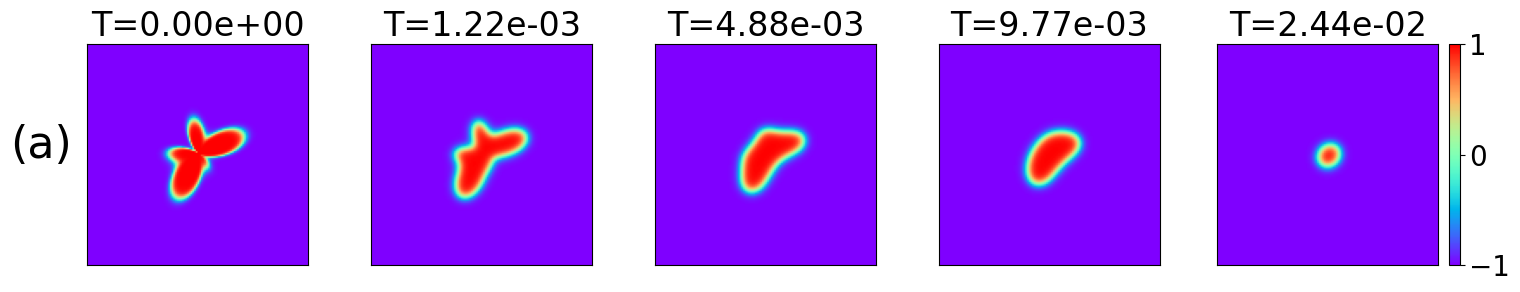

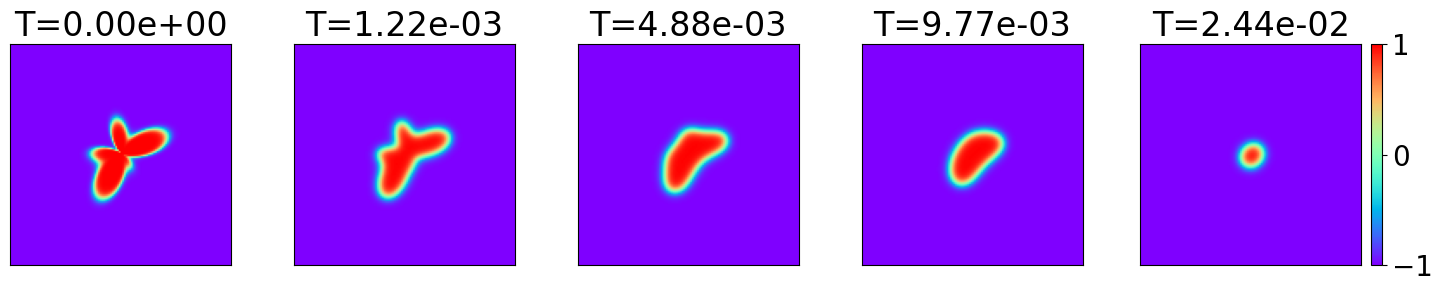

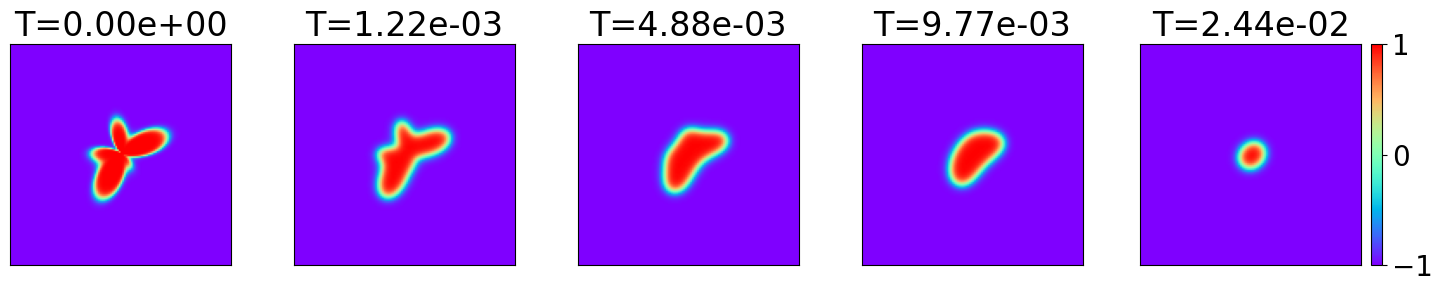

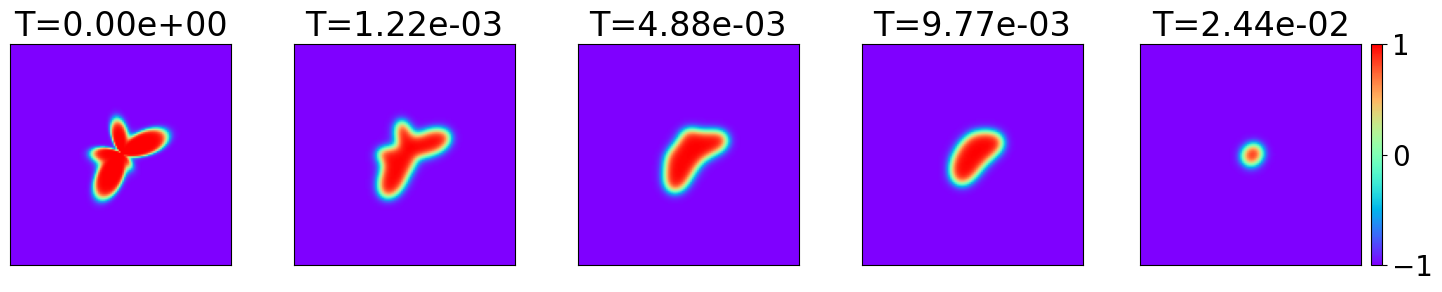

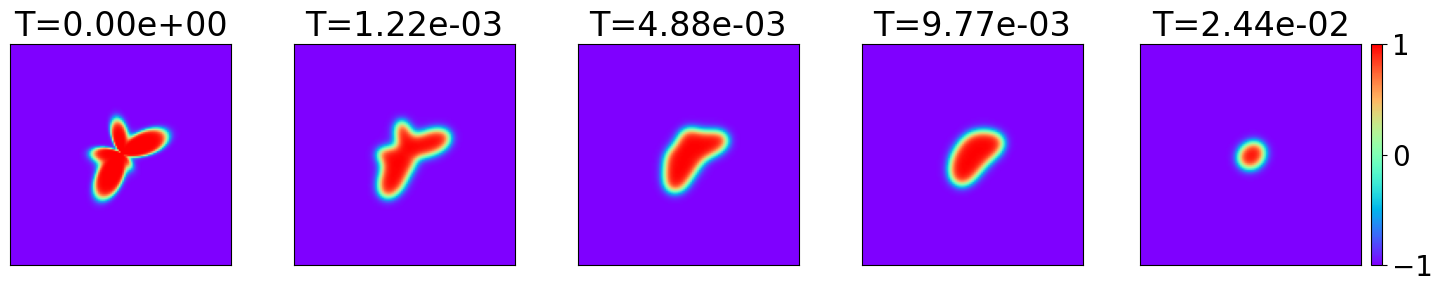

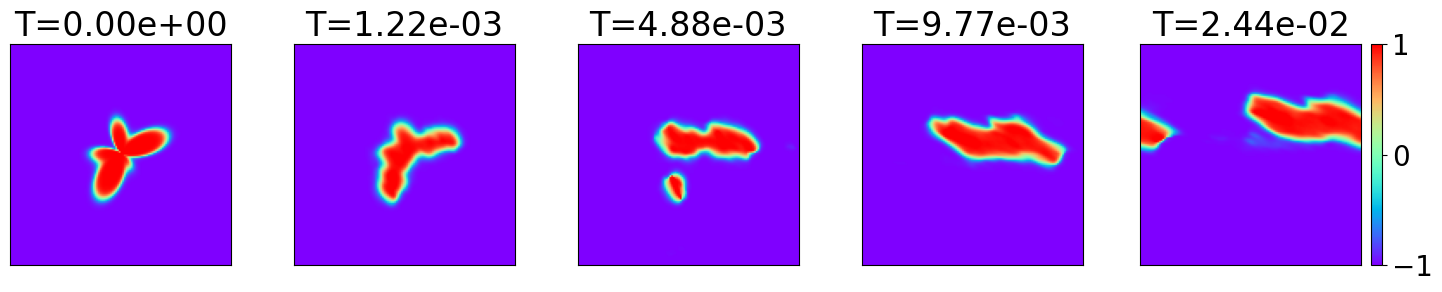

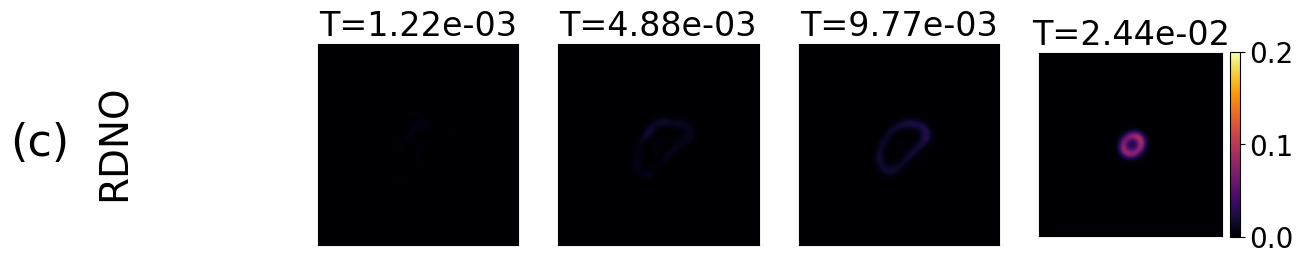

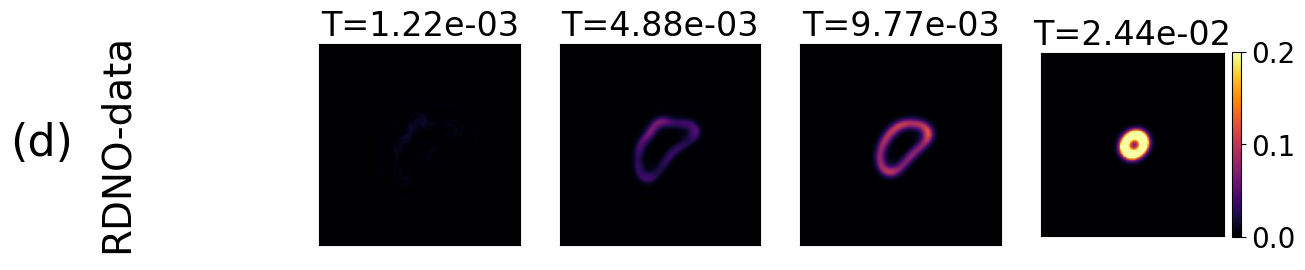

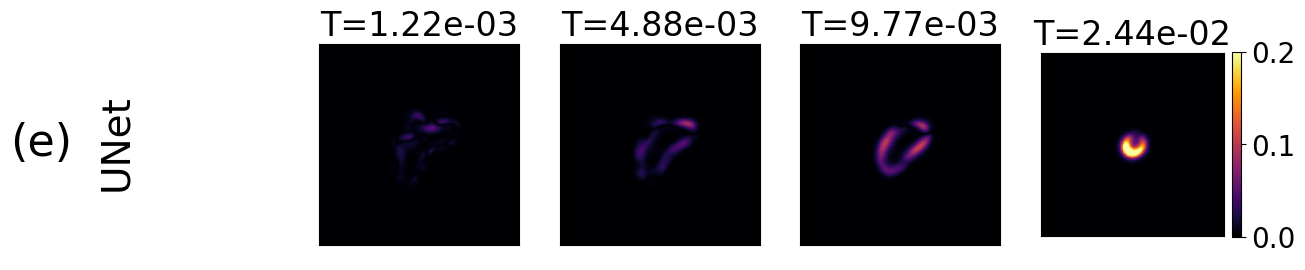

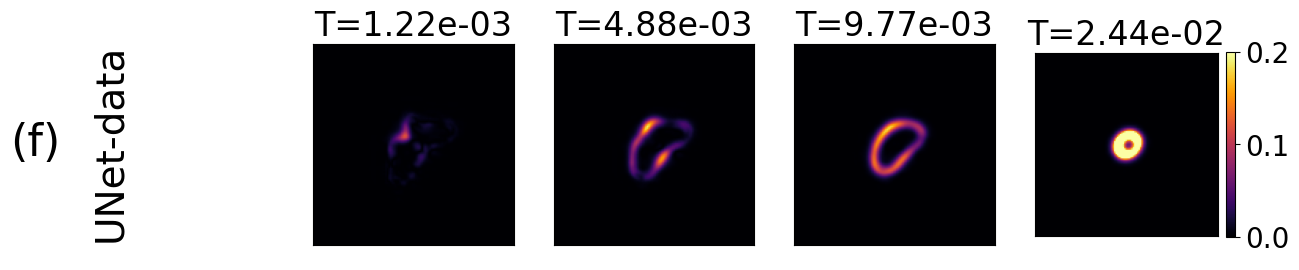

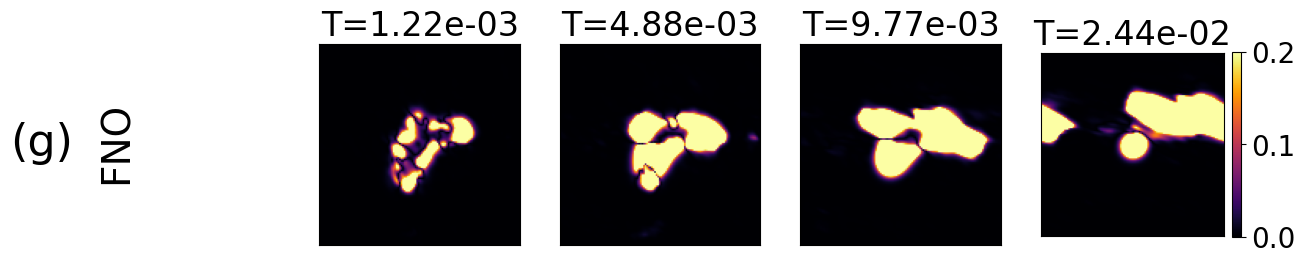

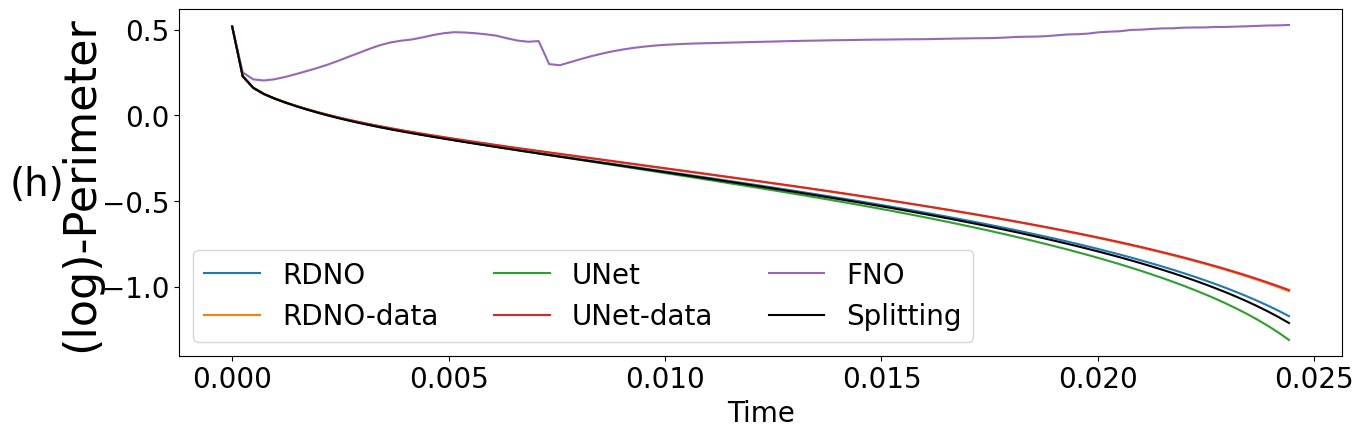

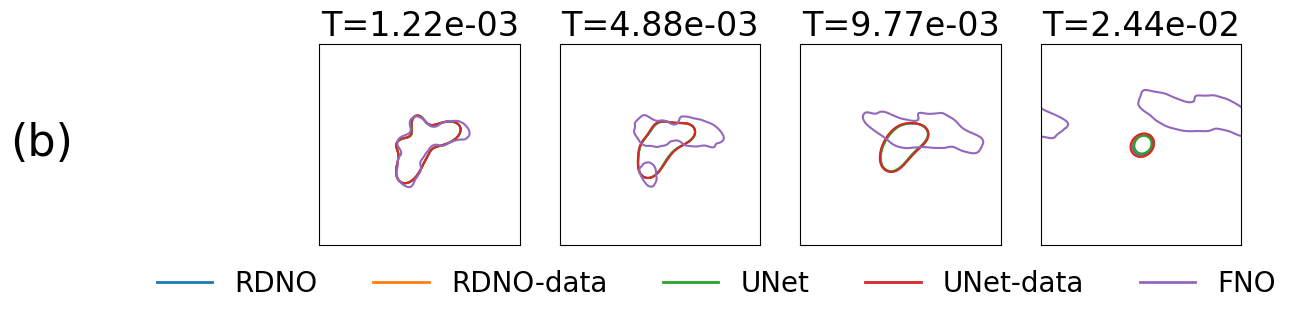

In [160]:
freq_IOD = [0, 5, 20, 40, 100]
drawDiagram(f_init, freq_IOD, config="IOD", ve=-0.4, he=(-0.0045, -0.0035))

Eval time : 0.07361030578613281
Eval time : 45.88067317008972
Eval time : 45.8403844833374
Eval time : 1.256580114364624
Eval time : 1.2898550033569336
Eval time : 3.4429683685302734
max abs_err at 3 : 0.010261550889424709
max abs_err at 10 : 0.05060092694523266
max abs_err at 40 : 0.0636396815024286
max abs_err at 100 : 0.33876802592542515
max abs_err at 3 : 0.01579556347756972
max abs_err at 10 : 0.0963939589904581
max abs_err at 40 : 0.20328658448818038
max abs_err at 100 : 1.077970298370301
max abs_err at 3 : 0.10590727081531337
max abs_err at 10 : 0.2012762103726582
max abs_err at 40 : 0.1062545737924574
max abs_err at 100 : 0.18223473290063552
max abs_err at 3 : 0.07336591249060792
max abs_err at 10 : 0.16085574979092662
max abs_err at 40 : 0.1963453488032709
max abs_err at 100 : 1.0114070300984945
max abs_err at 3 : 0.8694978661583849
max abs_err at 10 : 1.116696533009017
max abs_err at 40 : 1.8587069852204963
max abs_err at 100 : 2.018036625397871


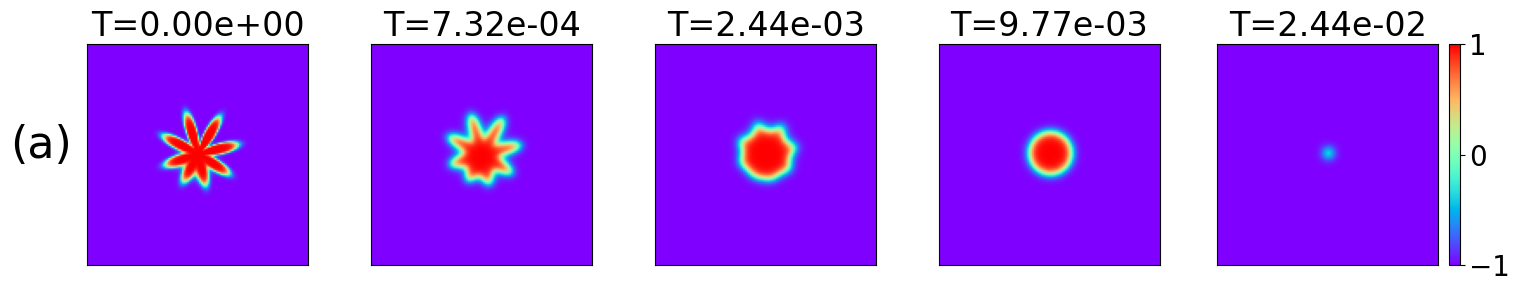

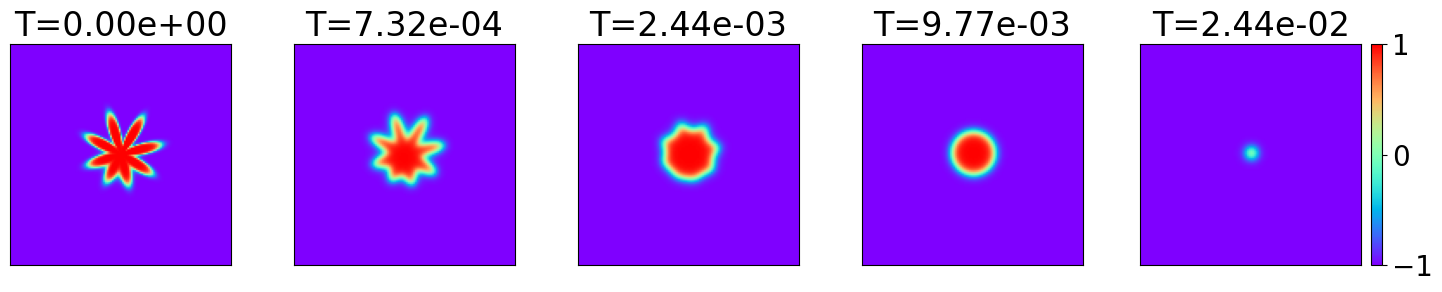

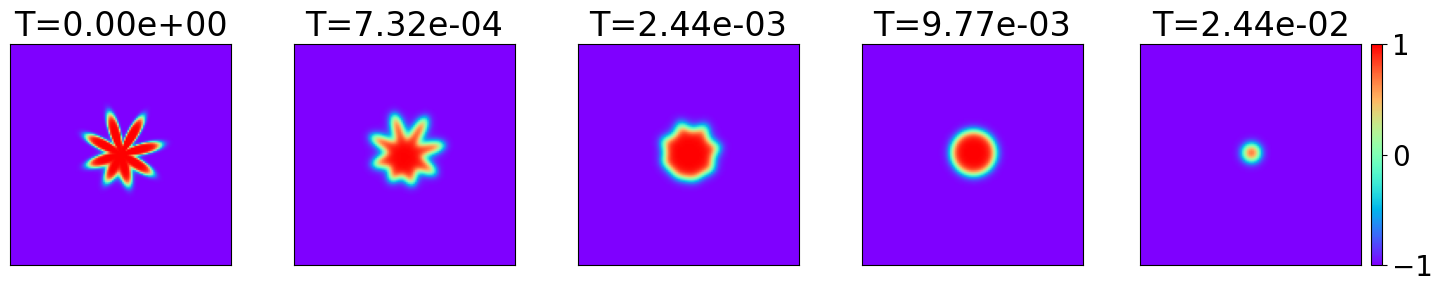

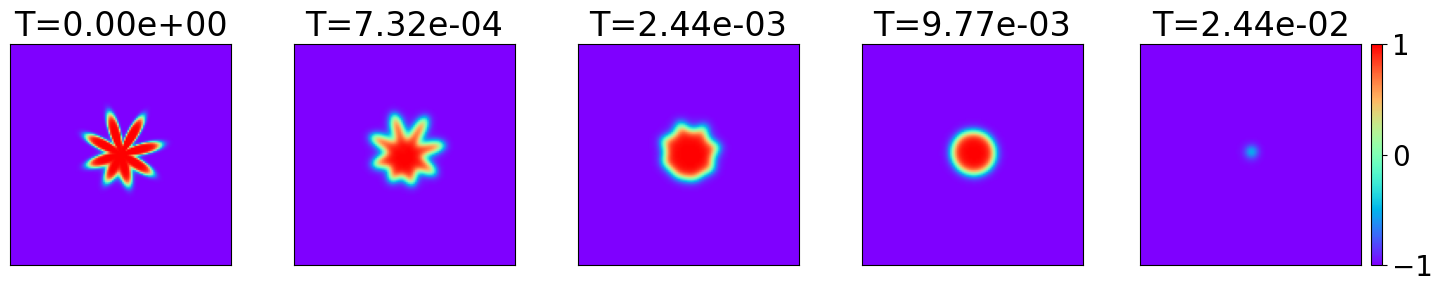

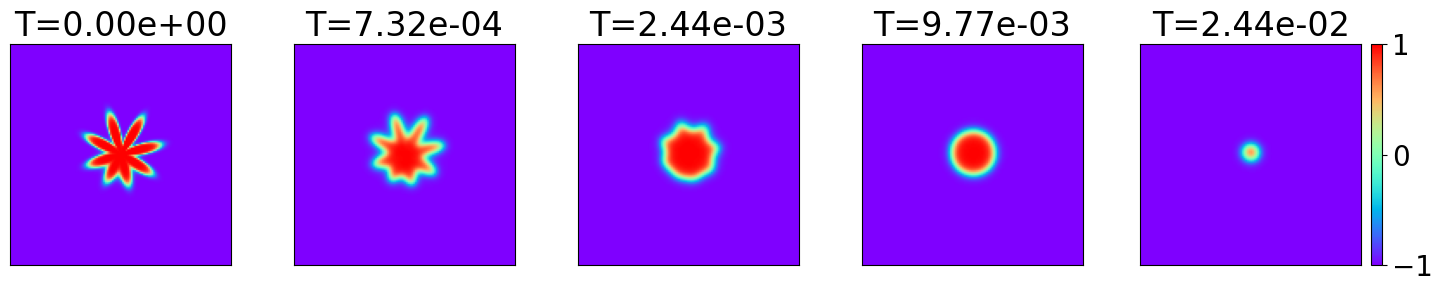

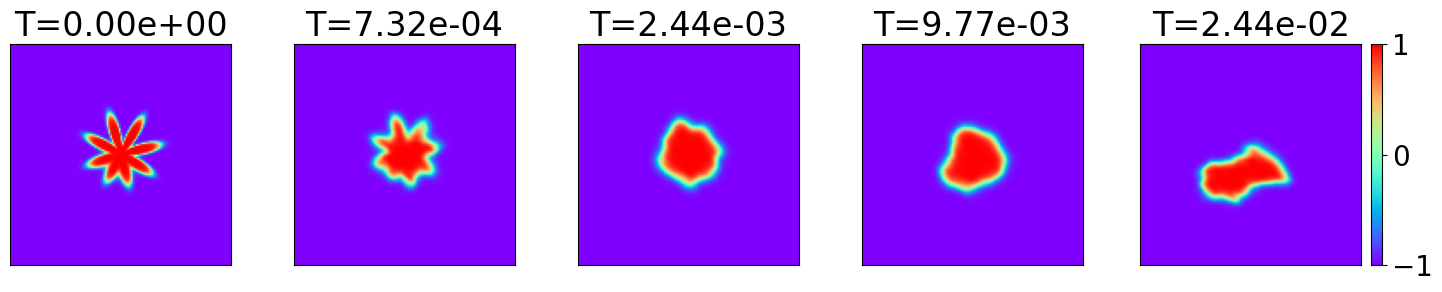

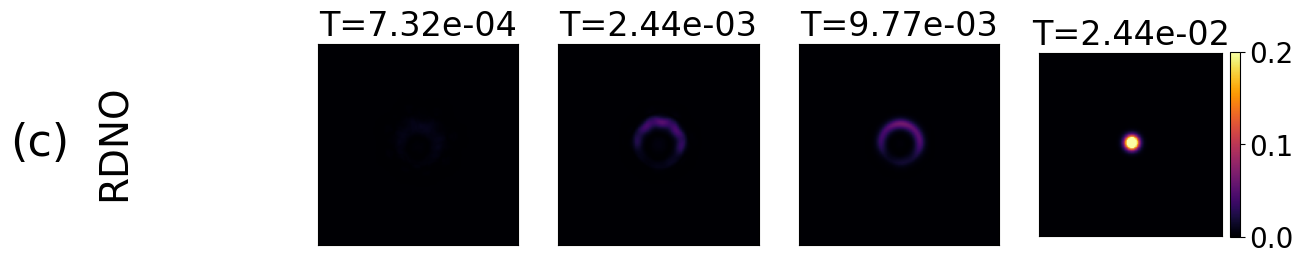

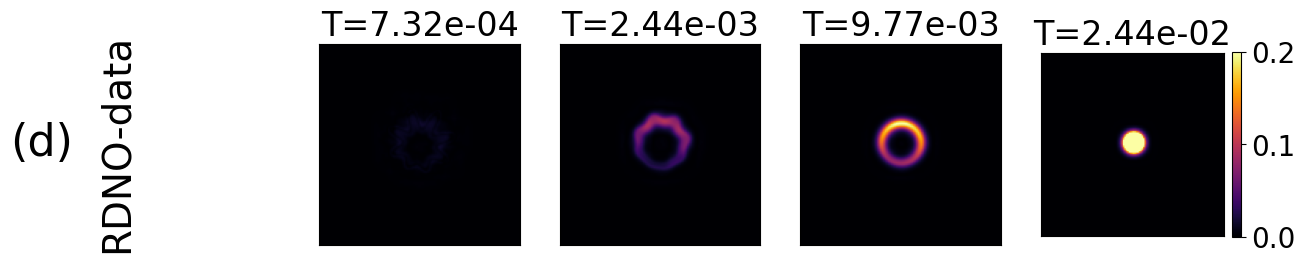

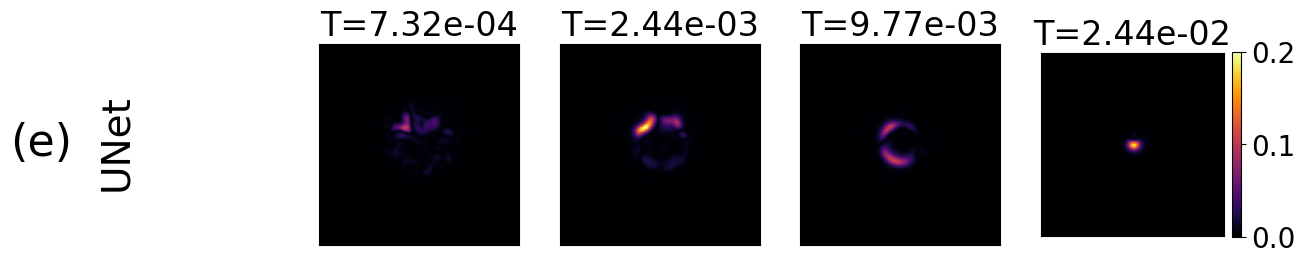

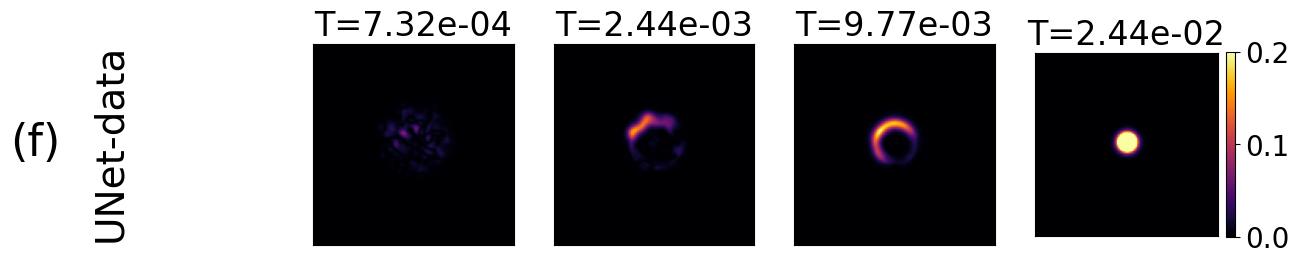

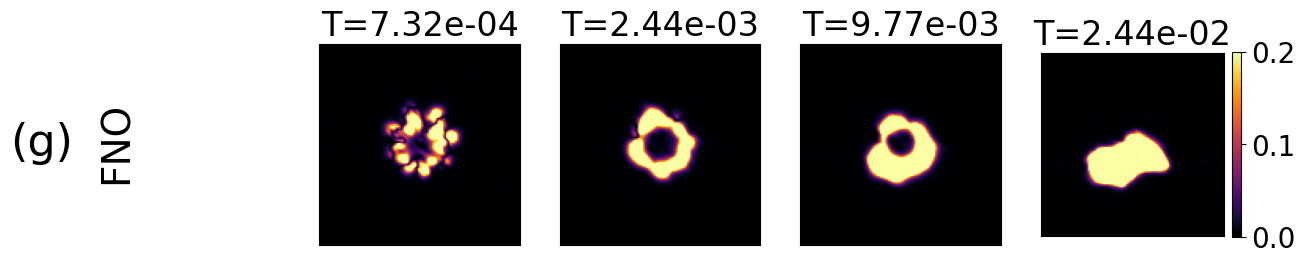

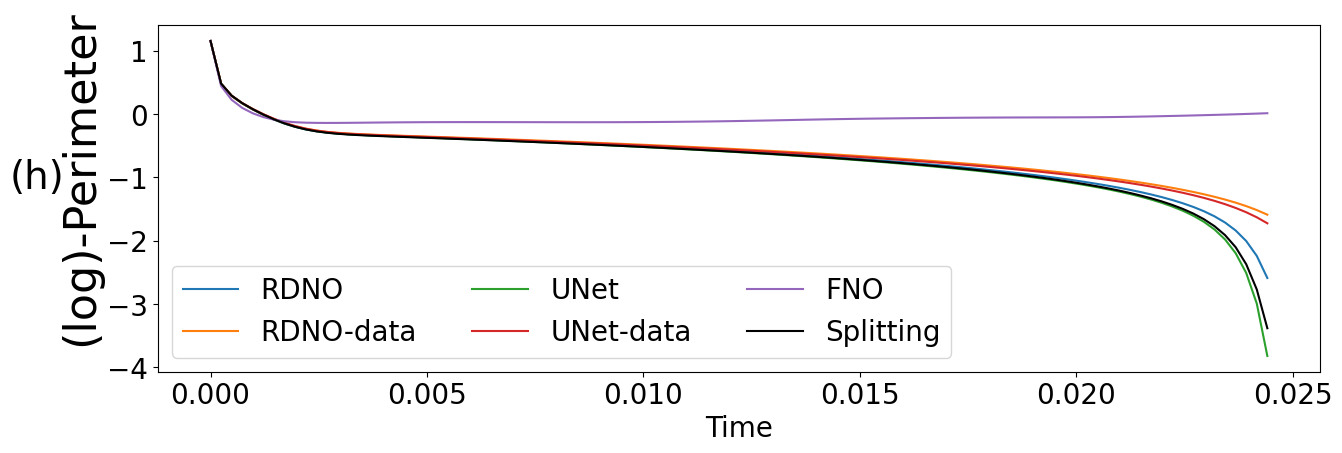

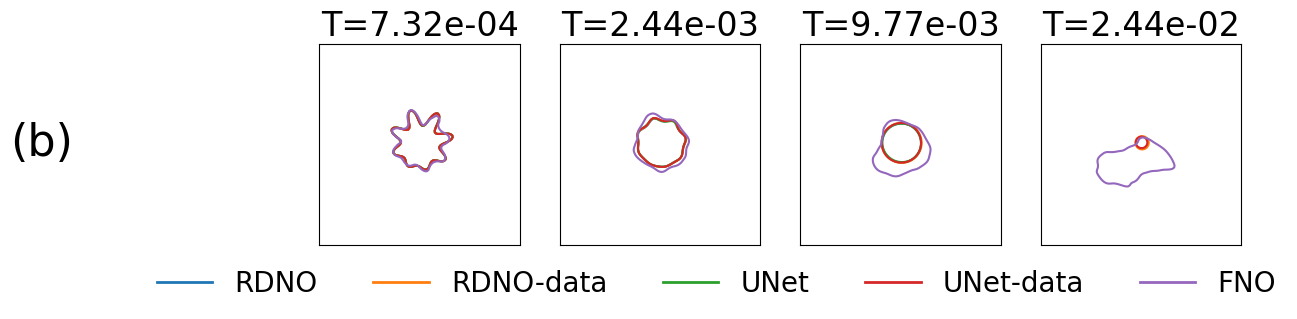

In [161]:
# _ = eval_num(f_init, freq = [0, 5, 20, 40, 100], title_name = "M=5", savepath="ac_in-test.png")
# #u_splittings = eval_num(f_init2, freq = freq_OOD, title_name = "M=8", savepath="ac_out-test.png")

freq_OOD = [0, 3, 10, 40, 100]
drawDiagram(f_init2, freq_OOD, config="OOD", ve=-1, he=[-0.0040, -0.0030])


Eval time : 0.08552312850952148
Eval time : 18.517119646072388
Eval time : 18.46321678161621
Eval time : 0.5148067474365234
Eval time : 0.5158770084381104
Eval time : 1.3284916877746582
max abs_err at 10 : 0.018832654244355873
max abs_err at 20 : 0.008378333852902653
max abs_err at 30 : 0.02021429532099056
max abs_err at 40 : 0.055598982636125394
max abs_err at 10 : 0.05219156698786831
max abs_err at 20 : 0.04816869242545091
max abs_err at 30 : 0.09174297386881497
max abs_err at 40 : 0.3084916096048931
max abs_err at 10 : 0.13326191170019397
max abs_err at 20 : 0.17866545338015027
max abs_err at 30 : 0.1851607933406863
max abs_err at 40 : 0.17435754444831728
max abs_err at 10 : 0.07902069666083134
max abs_err at 20 : 0.09537978381903885
max abs_err at 30 : 0.16985450495864243
max abs_err at 40 : 0.41354056251314947
max abs_err at 10 : 2.0068985459214104
max abs_err at 20 : 2.005580114860189
max abs_err at 30 : 2.008313718182377
max abs_err at 40 : 2.0095511122733605


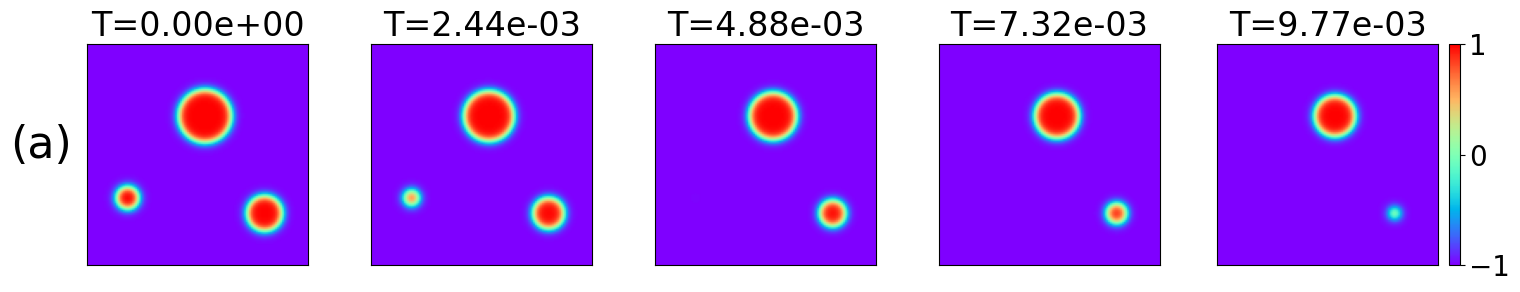

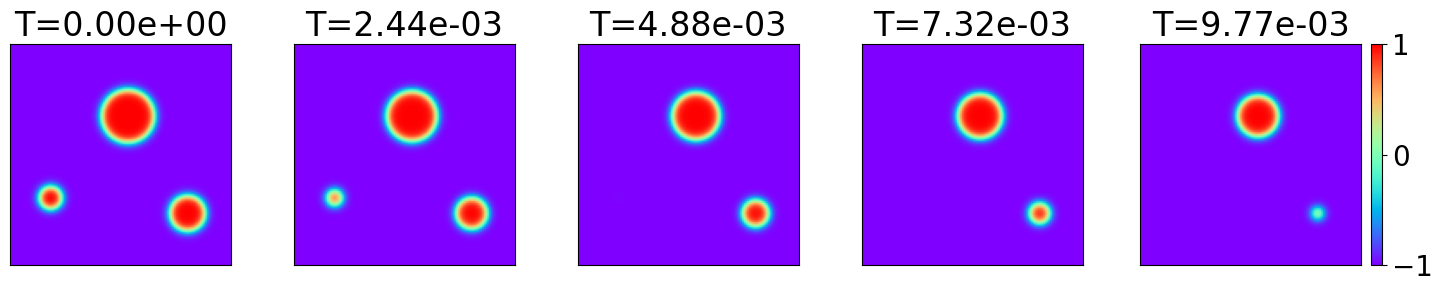

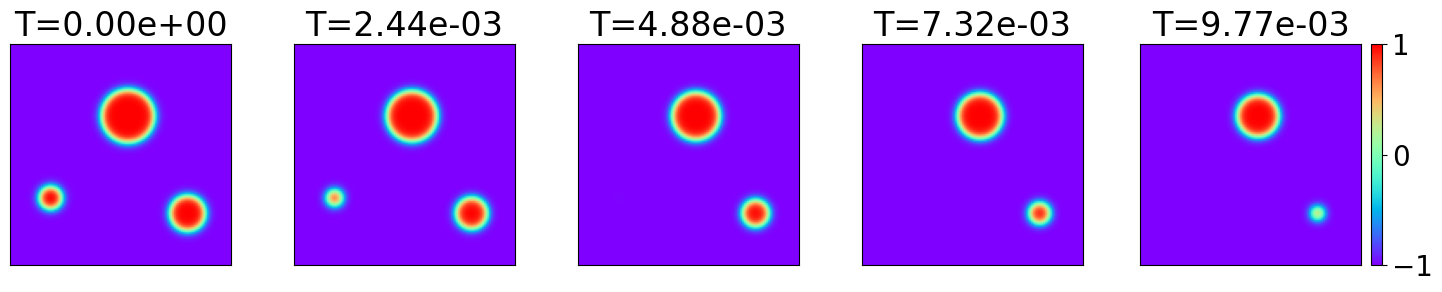

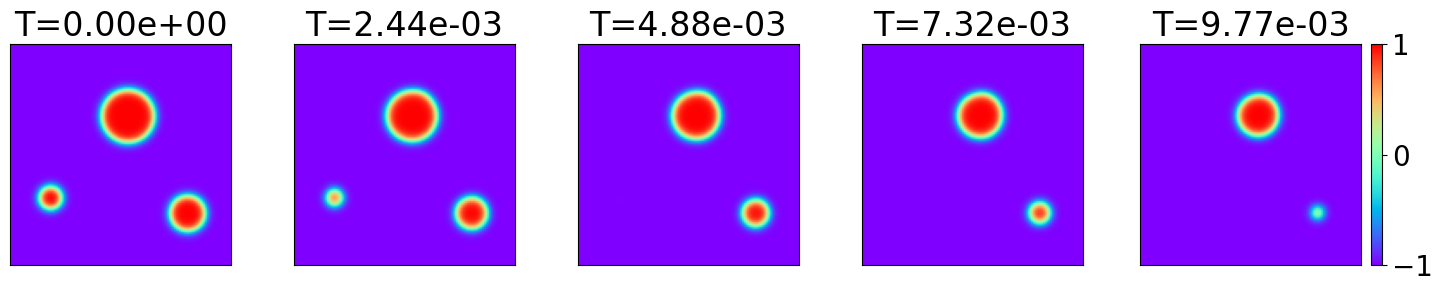

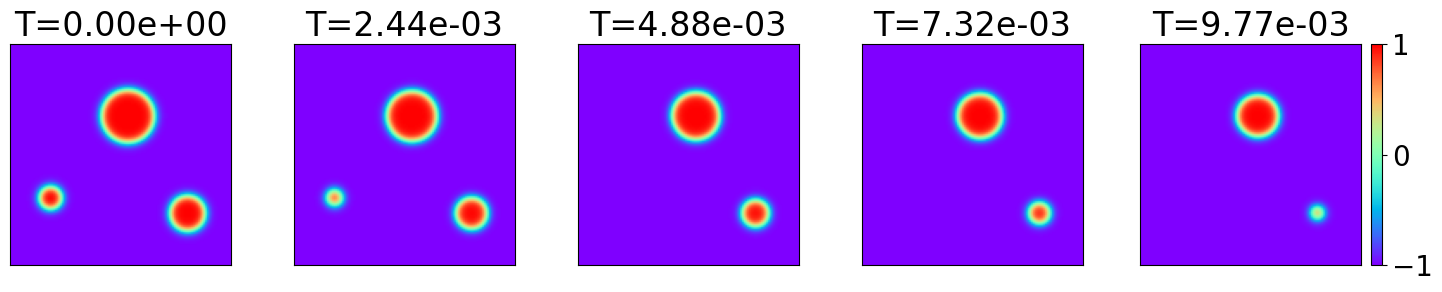

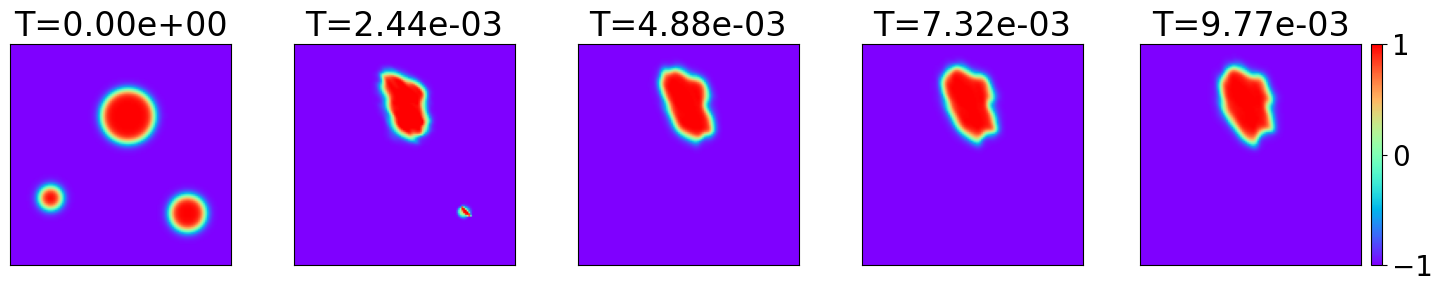

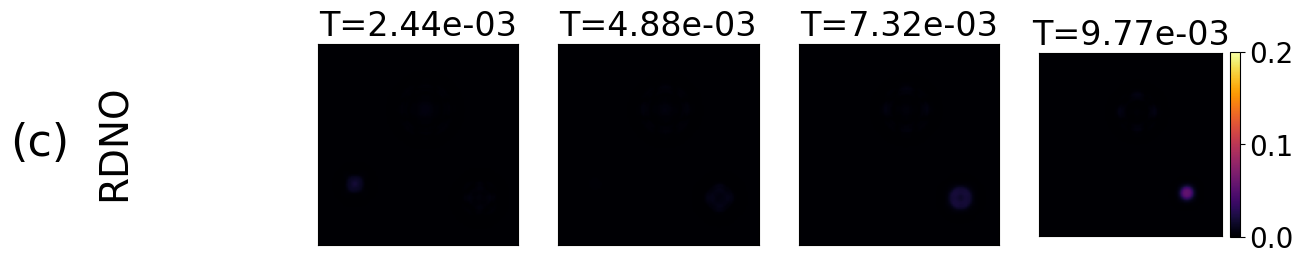

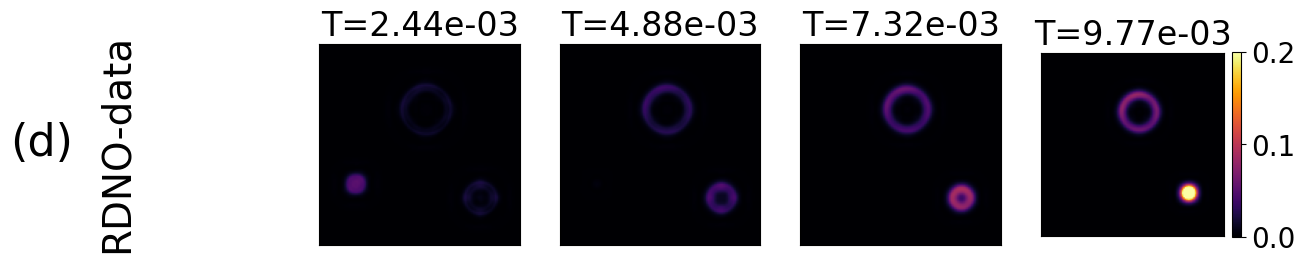

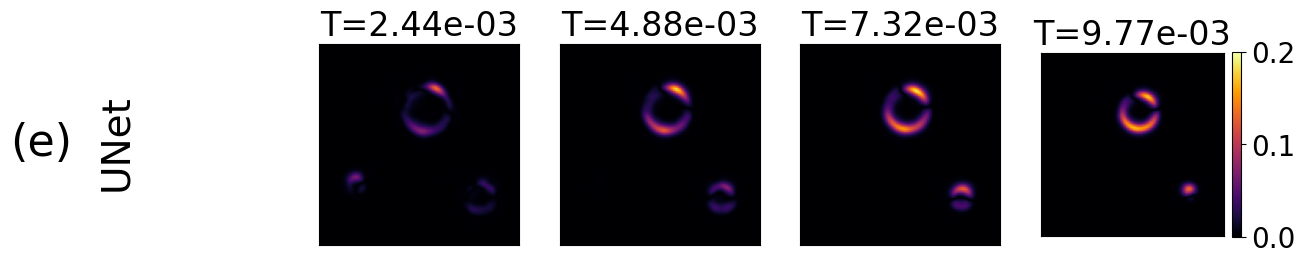

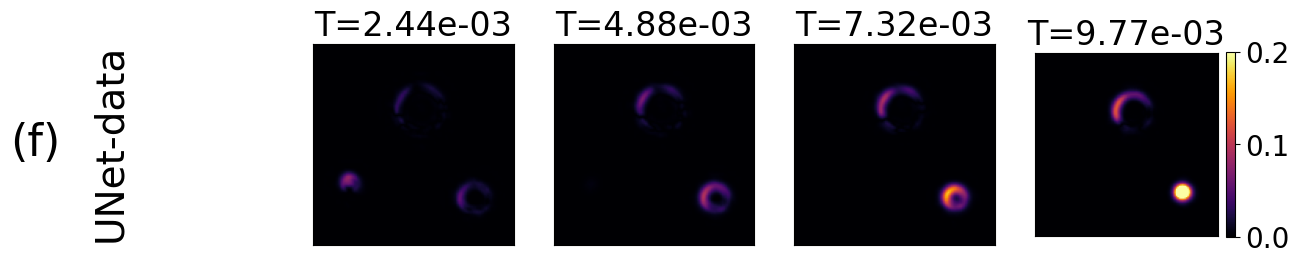

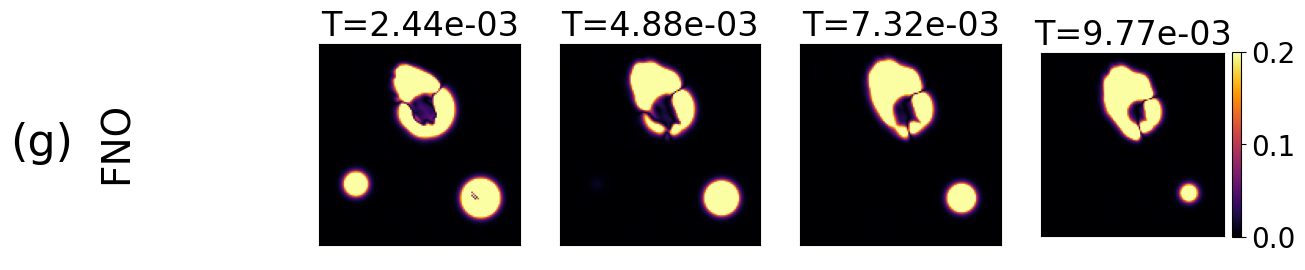

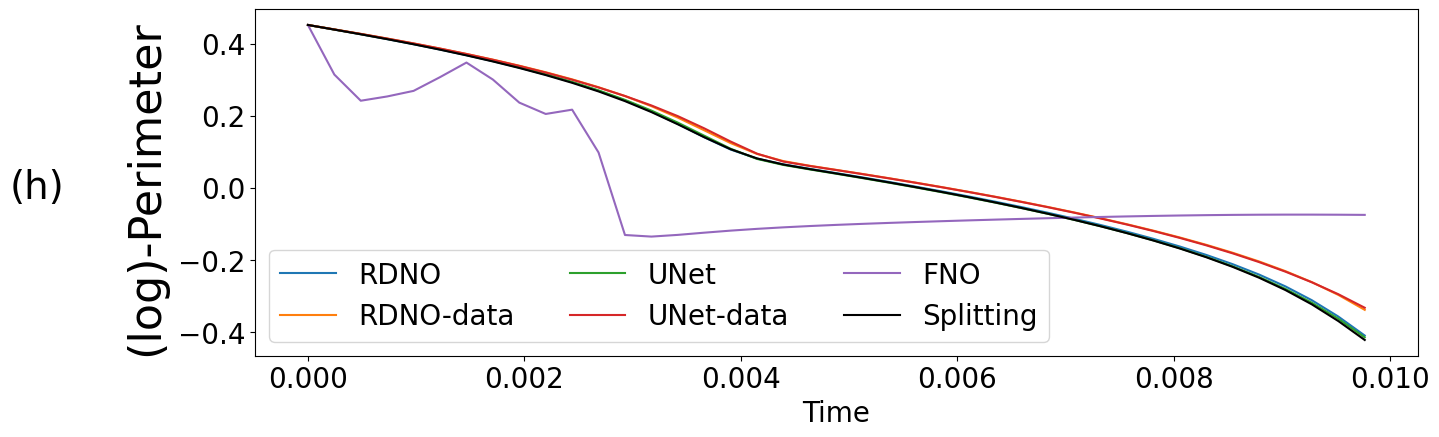

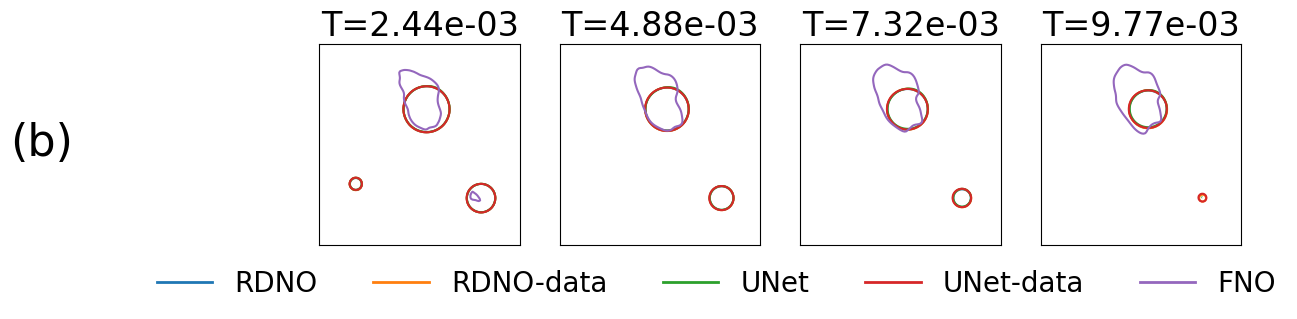

In [162]:
freq_multi = [0, 10, 20, 30, 40]
drawDiagram(multi, freq_multi, config="multi", ve=0.0, he=[-0.0025, -0.0015])

In [163]:
# print("==============IOD rel error===============")
# compare_NN(f_init, model_rdno)
# compare_NN(f_init, model_rdno_data)
# compare_NN(f_init, model_Unet)
# compare_NN(f_init, model_Unet_data)
# compare_NN(f_init, model_fno)
# 
# 
# print("==============OOD rel error===============")
# compare_NN(f_init2, model_rdno)
# compare_NN(f_init2, model_rdno_data)
# compare_NN(f_init2, model_Unet)
# compare_NN(f_init2, model_Unet_data)
# compare_NN(f_init2, model_fno)
# print("==============Multi rel error===============")
# compare_NN(multi, model_rdno)
# compare_NN(multi, model_rdno_data)
# compare_NN(multi, model_Unet)
# compare_NN(multi, model_Unet_data)
# compare_NN(multi, model_fno)
# 
# print("==============Random rel error===============")
# compare_NN(random_init, model_rdno, freq=3)
# compare_NN(random_init, model_rdno_data, freq=3)
# compare_NN(random_init, model_Unet, freq=3)
# compare_NN(random_init, model_Unet_data,freq=3)
# compare_NN(random_init, model_fno, freq=3)

In [164]:
#eval_DR(f_init, model, savepath="ac-ritz-vs-data-in.png")


In [165]:
# eval_DR(f_init2, model,savepath="ac-ritz-vs-data-out.png", freq=5)


In [166]:
#eval_DR(multi, model, model_name=model_name, savepath="ac-ritz-vs-data-multi.png")

In [167]:
# eval_num(random_init, freq = 3*np.arange(5), savepath='ac-splitting-random.png', title_name="Splitting")
# eval_NN(random_init, model, freq = 3*np.arange(5), savepath='ac-ritz-random.png', title_name=model_name)
# eval_NN(random_init, model2, freq = 3*np.arange(5), savepath='ac-data-random.png', title_name=model_name, method_name="Data-Driven")

In [168]:
# eval_DR(random_init, model, freq=3, model_name = model_name, savepath="ac-ritz-vs-data-random.png", included_num=True)